# Phrase Inference

Run the trained phrase-detection model on a new song and export an importable label JSON.

Shared feature/label logic is imported from `scripts/phrase_detection_v1.py` so it
stays identical to training (no train/serve skew). This notebook never trains or
overwrites a model.

In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import joblib
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Make the shared module importable
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from phrase_detection_v1 import (
    TrackLabels,
    PhraseMarker,
    extract_track_features,
    _with_context,
    CONTEXT_BARS,
)

In [6]:
# --- Knobs: edit these per song ---
INFER_AUDIO_PATH = PROJECT_ROOT / "data" / "audio" / "BMJOpen Your Mind.m4a"
INFER_BPM        = 160.0   # must be accurate
INFER_OFFSET     = 0.000   # downbeat offset in seconds, must be accurate
INFER_MODEL_PATH = PROJECT_ROOT / "models" / "phrase_detection" / "phrase_detection_v1.joblib"

In [7]:
# --- Load model + run inference ---
bundle = joblib.load(INFER_MODEL_PATH)
infer_model, infer_le = bundle["model"], bundle["label_encoder"]

_dur = librosa.get_duration(path=str(INFER_AUDIO_PATH))
infer_track = TrackLabels(
    track_name=INFER_AUDIO_PATH.stem,
    file_name=INFER_AUDIO_PATH.name,
    duration=_dur,
    bpm=INFER_BPM,
    downbeat_offset=INFER_OFFSET,
    markers=[PhraseMarker(phrase_id="unknown", bar_count=0, time=INFER_OFFSET)],
)

feats, _, segs = extract_track_features(infer_track, audio_dir=INFER_AUDIO_PATH.parent)
feats_ctx = _with_context(feats, context=CONTEXT_BARS)
preds = infer_le.inverse_transform(infer_model.predict(feats_ctx))
proba = infer_model.predict_proba(feats_ctx)

print(f"{INFER_AUDIO_PATH.name}: {len(preds)} bars predicted")

/var/folders/kt/4s5xbhsd2n7cc32120jp4fr40000gn/T/ipykernel_85320/1184497573.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  _dur = librosa.get_duration(path=str(INFER_AUDIO_PATH))
/Users/eerr/Documents/Projects/Timecode/-meow/scripts/phrase_detection_v1.py:166: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(audio_path.as_posix(), sr=sr, mono=True)
/Users/eerr/Documents/Projects/Timecode/-meow/.venv/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


BMJOpen Your Mind.m4a: 120 bars predicted


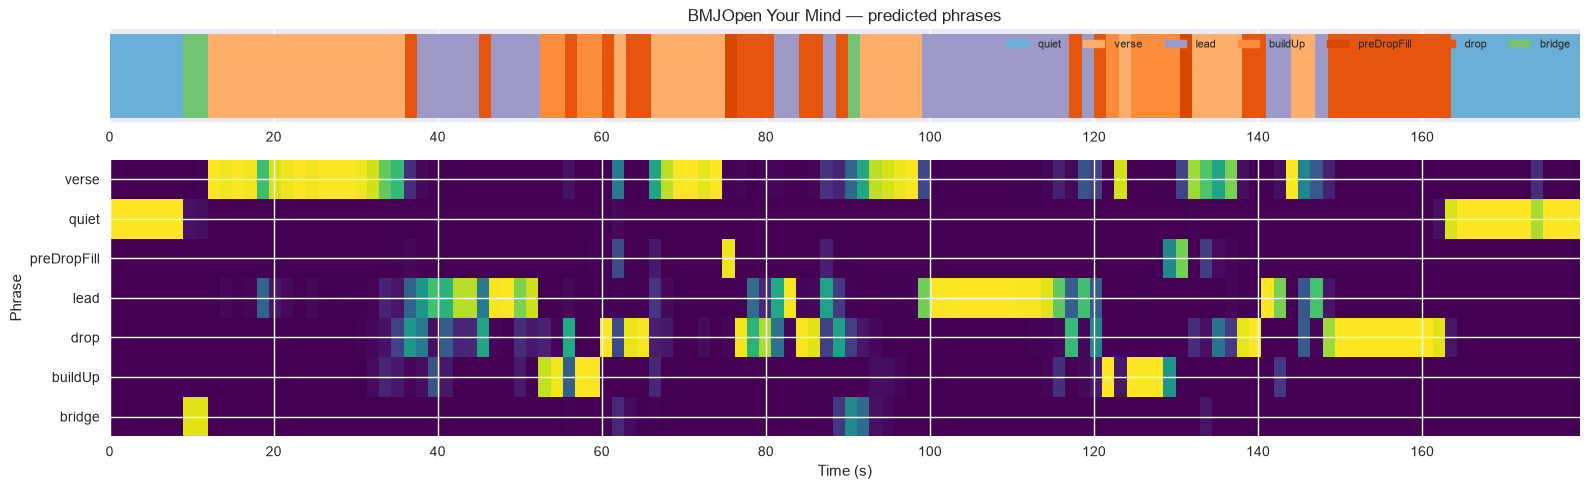

,bar,start,end,prediction
0,0,0.0,1.50,quiet
1,1,1.5,3.00,quiet
2,2,3.0,4.50,quiet
3,3,4.5,6.00,quiet
4,4,6.0,7.50,quiet
...,...,...,...,...
115,115,172.5,174.00,quiet
116,116,174.0,175.50,quiet
117,117,175.5,177.00,quiet
118,118,177.0,178.50,quiet


In [8]:
# --- Visualize ---
PHRASE_COLORS = {
    "quiet":       "#6baed6",
    "verse":       "#fdae6b",
    "lead":        "#9e9ac8",
    "buildUp":     "#fd8d3c",
    "preDropFill": "#d94801",
    "drop":        "#e6550d",
    "bridge":      "#74c476",
}
default_color = "#cccccc"

fig, (ax_timeline, ax_proba) = plt.subplots(2, 1, figsize=(16, 5),
    gridspec_kw={"height_ratios": [1, 3]}, sharex=False)

for seg, pred in zip(segs, preds):
    ax_timeline.barh(0, seg.end_time - seg.start_time, left=seg.start_time,
                     height=1, color=PHRASE_COLORS.get(pred, default_color), edgecolor="none")
ax_timeline.set_xlim(segs[0].start_time, segs[-1].end_time)
ax_timeline.set_yticks([])
ax_timeline.set_title(f"{INFER_AUDIO_PATH.stem} — predicted phrases")
legend_handles = [Patch(color=c, label=l) for l, c in PHRASE_COLORS.items()]
ax_timeline.legend(handles=legend_handles, loc="upper right", fontsize=8, ncol=len(PHRASE_COLORS))

ax_proba.imshow(proba.T, aspect="auto", origin="lower",
    extent=[segs[0].start_time, segs[-1].end_time, -0.5, len(infer_le.classes_) - 0.5],
    cmap="viridis", vmin=0, vmax=1)
ax_proba.set_yticks(range(len(infer_le.classes_)))
ax_proba.set_yticklabels(infer_le.classes_)
ax_proba.set_xlabel("Time (s)")
ax_proba.set_ylabel("Phrase")

plt.tight_layout()
plt.show()

infer_df = pd.DataFrame({"bar": range(len(preds)),
    "start": [s.start_time for s in segs],
    "end": [s.end_time for s in segs],
    "prediction": preds})
infer_df

In [ ]:
# --- Export predictions as label JSON (importable into the website) ---
import json

INFER_OUTPUT_PATH = INFER_AUDIO_PATH.with_suffix(".infer.json")

# Each marker sits at the last bar of a phrase run
markers = []
for i, (seg, pred) in enumerate(zip(segs, preds)):
    if i == len(preds) - 1 or preds[i + 1] != pred:
        markers.append({
            "phraseId": pred,
            "time": seg.start_time,
            "barCount": seg.bar_index,
            "msSinceStart": round(seg.start_time * 1000),
        })

label_json = {
    "version": 3,
    "fileName": INFER_AUDIO_PATH.name,
    "duration": _dur,
    "bpm": INFER_BPM,
    "downbeatOffset": INFER_OFFSET,
    "cueTime": 0,
    "quantizeEnabled": True,
    "phraseMarkers": markers,
}

with open(INFER_OUTPUT_PATH, "w") as f:
    json.dump(label_json, f, indent=2)

print(f"Saved to {INFER_OUTPUT_PATH}")
print(f"{len(markers)} phrase markers")
pd.DataFrame(markers)